# 实验 3：RoPE 原理——位置编码与相对位置



## 1. 不考虑位置编码时的注意力分数

先暂时不考虑任何位置编码。对于两个 token，我们用它们对应的查询向量 $q$ 和键向量 $k$ 来计算原始注意力分数：

$$
s^{\mathrm{raw}}=q^\top k
$$

这个分数只取决于 $q$ 和 $k$ 本身，而与它们在序列中的位置无关。

例如，token A 和 token B 原本分别位于位置 1 和位置 5，它们的注意力分数是

$$
q_A^\top k_B
$$

如果把这两个 token 移到位置 10 和位置 20，只要它们对应的向量没有改变，得到的仍然是

$$
q_A^\top k_B
$$

因此，在不考虑位置编码的情况下，attention 只能感受到两个 token 在内容上的相关性，却感受不到它们的位置不同所带来的影响。

如果希望 attention 感受到 token 的位置信息，我们就需要让位置参与两个 token 的相关性计算。也就是说，希望两个 token 的原始注意力分数不仅取决于它们对应的 Q 和 K，还与它们在序列中的位置有关：

$$
s^{\mathrm{raw}}=f(q,k,m,n)
$$

其中 $m$ 和 $n$ 分别表示两个 token 的位置。

RoPE 所采用的思路，就是让位置通过对 Q 和 K 的旋转进入这一计算过程。


## 2. 用旋转编码位置

先从一个二维向量开始。设一个 token 的表示为

$$
x=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$

我们可以通过旋转这个向量来编码它所处的位置。设 token 位于位置 $m$，每向后移动一个位置就旋转固定的角度 $\theta$，那么位置 $m$ 对应的旋转角度为

$$
\phi_m=m\theta
$$

于是，该 token 在位置 $m$ 时的表示可以写成

$$
x_m=R(m\theta)x
$$

其中 $R(\phi)$ 表示将二维向量旋转 $\phi$ 角度的旋转矩阵

这样，同一个向量处于不同位置时，会对应不同的旋转角度，从而得到不同的表示。位置就通过向量方向的变化被编码了下来。

### 2.1 旋转后的 Q 和 K

现在把这种旋转应用到 Q 和 K 上。设位置 $m$ 的 token 对应查询向量 $q_m$，位置 $n$ 的 token 对应键向量 $k_n$。在不考虑位置编码时，它们的原始注意力分数为

$$
s_{mn}=q_m^\top k_n
$$

加入位置旋转后，Q 和 K 分别变为

$$
q_m'=R(m\theta)q_m
$$

$$
k_n'=R(n\theta)k_n
$$

因此，加入 RoPE 后的注意力分数为

$$
s_{mn}'=q_m'^\top k_n'
$$

也就是

$$
s_{mn}'
=
\bigl(R(m\theta)q_m\bigr)^\top
\bigl(R(n\theta)k_n\bigr)
$$

利用旋转矩阵满足

$$
R(\phi)^\top=R(-\phi)
$$

可以得到

$$
s_{mn}'
=
q_m^\top R(-m\theta)R(n\theta)k_n
$$

而二维旋转满足

$$
R(a)R(b)=R(a+b)
$$

因此

$$
\boxed{
s_{mn}'
=
q_m^\top R\bigl((n-m)\theta\bigr)k_n
}
$$

可以看到，加入 RoPE 后，注意力分数不仅取决于 $q_m$ 和 $k_n$ 的内容，还与两个 token 的位置有关，而且位置最终以它们的差 $n-m$ 出现

<p align="center">
  <img src="../assets/rope_demo.gif" alt="RoPE 演示" width="90%">
</p>

对比第一图可以看到，引入旋转位置编码后，注意力分数立刻发生了改变（如第二图）；更重要的是，随着 Token 位置的调换，计算出的分数也会随之变化（如第三图）。attention 成功感知了 token 不同位置的差异。

## 3. 相对位置

前面的推导表明，加入 RoPE 后，Q 和 K 的旋转会使注意力分数中出现两个位置之差 $n-m$。

为了直观地观察这一性质，下面固定一个查询向量 $q$ 和一个键向量 $k$，让它们分别位于位置 $m,n\in{0,1,\ldots,6}$。对于每一组位置，按照 RoPE 的方式分别旋转 Q 和 K，再计算旋转后的内积，得到一个 $7\times7$ 的注意力分数矩阵。

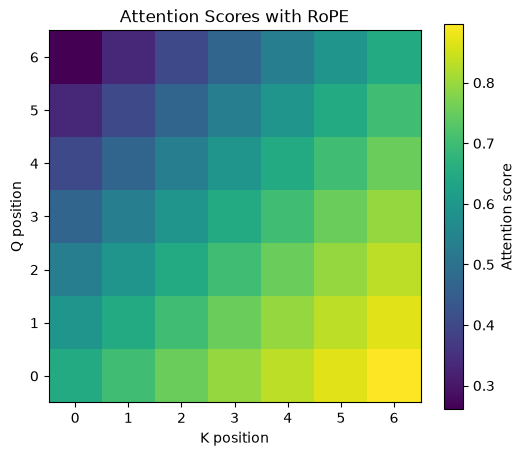

In [1]:
import torch
import matplotlib.pyplot as plt

q = torch.tensor([1.0, 0.5])
k = torch.tensor([0.8, -0.3])

theta = torch.pi / 40
positions = torch.arange(7)


def rotate(x, angle):
    c = torch.cos(angle)
    s = torch.sin(angle)

    R = torch.tensor([
        [c, -s],
        [s,  c]
    ])

    return R @ x


# 计算加入 RoPE 后的注意力分数
scores = torch.zeros(7, 7)

for m in positions:
    for n in positions:
        q_rot = rotate(q, m * theta)
        k_rot = rotate(k, n * theta)

        scores[m, n] = q_rot @ k_rot


# 可视化
plt.figure(figsize=(6, 5))

plt.imshow(
    scores.numpy(),
    origin="lower",
    aspect="equal"
)

plt.xticks(positions)
plt.yticks(positions)

plt.xlabel("K position")
plt.ylabel("Q position")
plt.title("Attention Scores with RoPE")

plt.colorbar(label="Attention score")

plt.show()

将得到的注意力分数画成热力图后，可以看到明显的对角线结构。

这是因为同一条对角线上的位置组合具有相同的相对位置。例如，位置组合 $(0,2)$ 和 $(1,3)$ 分别对应

$$
n-m=2
$$

虽然它们的绝对位置不同，但 Q 和 K 之间的旋转角度差相同，因此得到的注意力分数也相同。

类似地，对于任意满足

$$
n-m=d
$$

的位置组合，它们对应的注意力分数都相同。因此，在热力图中，相同相对位置的点会落在同一条对角线上，并呈现出相同的数值。

这与前面的推导完全一致

$$
s_{mn}'=q^\top R((n-m)\theta)k
$$

其中真正决定旋转关系的不是 $m$ 和 $n$ 各自的绝对位置，而是它们之间的差 $n-m$。

因此，从这个受控实验中，我们可以直观地观察到 RoPE 引入的相对位置性质：

$$
\boxed{\text{相同的相对位置}
\Longrightarrow
\text{相同的旋转关系}
\Longrightarrow
\text{相同的注意力分数}}
$$
